In [1]:
import numpy as np 
from netCDF4 import Dataset
import os
import tensorflow as tf
import argparse
import pandas as pd

2025-06-17 11:56:27.421620: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX512_VNNI AVX512_BF16
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-06-17 11:56:27.604060: I tensorflow/core/util/port.cc:104] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [2]:
pwd

'/gpfs/home4/thappe/HeaT/Notebooks'

In [3]:
HOME = "/home/thappe"

# HOME = "/scistor/ivm/the410"
# data_path= "/scistor/ivm/the410/PAPER3/"

In [4]:
os.chdir(f"{HOME}/HeaT")
#sys.path.append(os.path.expanduser('/home/thappe/HeaT'))

from HeaT.TFrecord_utils_ERA_v2 import *

### pieces of adjusted code below

now in TFrecord_utils_ERA_v2

In [7]:
# #READ IN HEATWAVE DATA
# years_i, day0_i, dates_i = loading_heatwave_data(f"{data_path_heatwaves}{test_heatwave_file}", nyears)
# #READ AND PREPROCESS CLIMATE DATA
# list_of_data = preprocessing_v3(["stream", "mslp"], data_path, nyears, method=method) 
# #CREATE HEATWAVE EVENTS
# events = data_to_events_v2(list_of_data, ["stream", "mslp"], 7, years_i, day0_i)

In [8]:
# #PROCESS EVENTS INTO TF RECORD FILES
# current_shard = 0
# img_in_current_shard = 0
# SAMPLES_PER_SHARD = len(events) #later zien of dit niet te groot is
# writer = tf.io.TFRecordWriter(f"{data_path}/tf_records/TF_record_ERA5_{startyear}-{endyear}_{method}_TEST.tfrecord")
# for i, event in enumerate(events):
#     if img_in_current_shard == SAMPLES_PER_SHARD:
#         writer.close()
#         #open new file
#         current_shard += 1
#         img_in_current_shard = 0
#         writer = tf.io.TFRecordWriter(f"{data_path}/tf_records/TF_record_ERA5_{startyear}-{endyear}_{method}_TEST.tfrecord")
#     #process current sample and write to file
#     tf_example = serialize_example(event, dates_i[i])
#     #print(tf_example)
#     writer.write(tf_example) #Serializetostring()
#     img_in_current_shard += 1
# writer.close()


# To create TFrecords

### set variables and run all code

In [11]:
### GLOBAL VARIABLES

## for snellius:
data_path = "/home/thappe/data"
data_path_heatwaves = f"{data_path}/heatwaves/"
data_path_climate = f"{data_path}/ERA5/"

# test_heatwave_file = "ERA5_LentisGrid_Tdynamic_1940-2023_90thPcntl_test.csv"
# t2m = "test"
# nyears = 2
# startyear=2022
# endyear=2023


# heatwave_file = "ERA5_1940_2023_lentis_EU_heatwave_clusters_p90mp21_cdopercentile.csv"
# t2m = "t2m"

# heatwave_file = "T2M_dynamic_ERA5_1940_2023_lentis_EU_heatwave_clusters_p90mp21_cdopercentile.csv"
# t2m = "t2m_dynamic"

heatwave_file = "T2M_minus_thermo_ERA5_1940_2023_lentis_EU_heatwave_clusters_p90mp21_cdopercentile.csv"
t2m = "t2m_minus_thermo"


method = "RAW" #"standardization_cut"
variables=["stream", "mslp"]

nyears = 84
startyear=1940
endyear=2023



In [12]:
data_to_TFrecord_v2(t2m=t2m,
                    heatwave_file=heatwave_file,
                    path_heatwaves=data_path_heatwaves, 
                    data_path = data_path,
                    variables=variables, 
                    path_climate=data_path_climate, 
                    nyears=nyears, 
                    event_len=7, 
                    method=method,
                    startyear=startyear, 
                    endyear=endyear)

Data is assumed to be from June-September with 122 days per year
/gpfs/home4/thappe/HeaT /gpfs/home4/thappe/data/ERA5
1940 2023
variable is stream
method is RAW, no standardization applied
variable is mslp
method is RAW, no standardization applied
Variable order is  ['stream', 'mslp']
stream_data.shape is (10248, 64, 192)
psl_data.shape is (10248, 64, 192)
duplicate count = 182


In [13]:
ls -lah /home/thappe/data/tf_records

total 5.3G
drwxr-x---  3 thappe thappe 4.0K Jun 17 11:57 ./
drwxrwx---+ 9 thappe thappe 4.0K Mar 18 17:26 ../
drwxr-x---  2 thappe thappe 4.0K Jun 16 17:02 old/
-rw-r-----  1 thappe thappe 904M Jun 17 11:56 TF_record_ERA5_t2m_1940-2023_RAW.tfrecord
-rw-r-----  1 thappe thappe 904M Mar 18 16:20 TF_record_ERA5_t2m_1940-2023_standardization_cut.tfrecord
-rw-r-----  1 thappe thappe 827M Jun 17 11:56 TF_record_ERA5_t2m_dynamic_1940-2023_RAW.tfrecord
-rw-r-----  1 thappe thappe 827M Mar 18 16:19 TF_record_ERA5_t2m_dynamic_1940-2023_standardization_cut.tfrecord
-rw-r-----  1 thappe thappe 971M Jun 17 11:57 TF_record_ERA5_t2m_minus_thermo_1940-2023_RAW.tfrecord
-rw-r-----  1 thappe thappe 971M Mar 18 16:19 TF_record_ERA5_t2m_minus_thermo_1940-2023_standardization_cut.tfrecord


# To read 

## data inlezen en kijken of het goed is gegaan

In [6]:
# tf_record_test_file = f"{data_path}/tf_records/TF_record_ERA5_2022-2023_standardization_cut_TEST.tfrecord"

In [12]:
t2m_name = "t2m_dynamic" 

assert t2m_name in ["t2m", "t2m_dynamic", "t2m_minus_thermo"], "data not available for this var"

tf_record_file = f"{data_path}/tf_records/TF_record_ERA5_{t2m_name}_1940-2023_standardization_cut.tfrecord"

In [13]:
data = load_tfrecords_ERA5(tf_record_file)

In [14]:
# #LOAD data from records
data_parsed = data.map(parse_function_full_era5)

#Get a sample to use for visualisation during training
data_testbatch = data.map(parse_function_full_era5).take(1) #selecting only one for visualisation

In [15]:
data_testbatch

<TakeDataset element_spec=(TensorSpec(shape=<unknown>, dtype=tf.float32, name=None), TensorSpec(shape=(), dtype=tf.int64, name=None), TensorSpec(shape=(), dtype=tf.int64, name=None), TensorSpec(shape=(), dtype=tf.int64, name=None))>

In [39]:

for element in data_testbatch.as_numpy_iterator(): #to convert to numpy elements
    array = np.transpose(element[0])
    stream_in = array[0, :, :, :] 
    psl_in = array[1, :, :, :]
    date = str(element[1]) + "_" + str(element[2]) + "_" + str(element[3]) 

# checking here why we don't have data after 2009

In [16]:
from datetime import date
dates = []

for element in data_parsed.as_numpy_iterator(): #to convert to numpy elements
    array = np.transpose(element[0])
    stream_in = array[0, :, :, :] 
    psl_in = array[1, :, :, :]
    iso_date = date(element[1], element[2], element[3]).isoformat() #year, month, date 
    date_date = date.fromisoformat(iso_date) #to datetime object 
    dates.append(date_date)

In [17]:
dates[-10:]

[datetime.date(2022, 8, 23),
 datetime.date(2022, 8, 26),
 datetime.date(2023, 7, 7),
 datetime.date(2023, 7, 8),
 datetime.date(2023, 7, 9),
 datetime.date(2023, 7, 17),
 datetime.date(2023, 7, 20),
 datetime.date(2023, 8, 7),
 datetime.date(2023, 8, 12),
 datetime.date(2023, 8, 17)]

### om te visualizeren hieronder

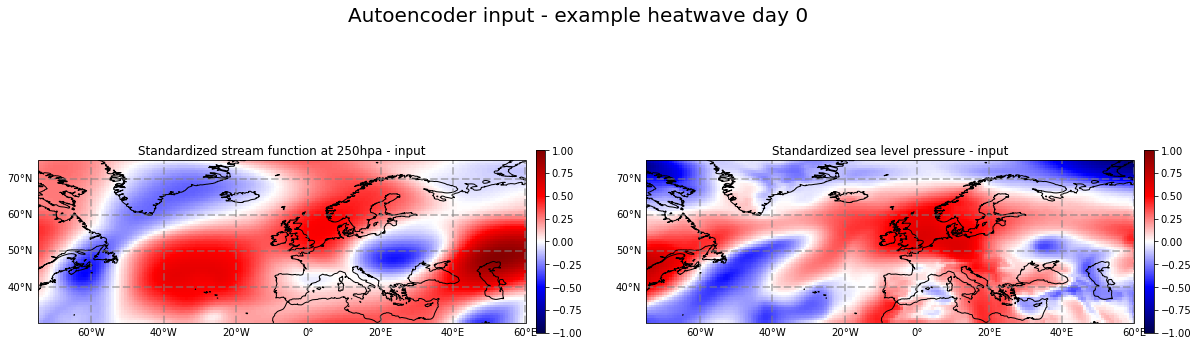

<Figure size 432x288 with 0 Axes>

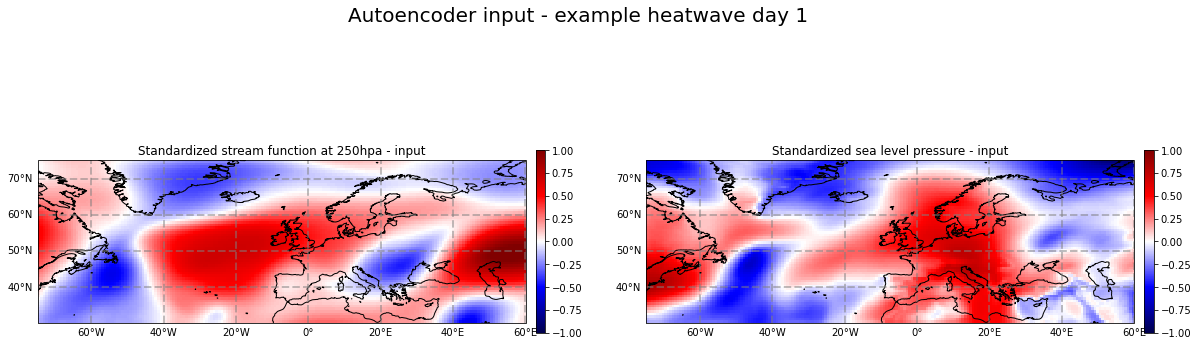

<Figure size 432x288 with 0 Axes>

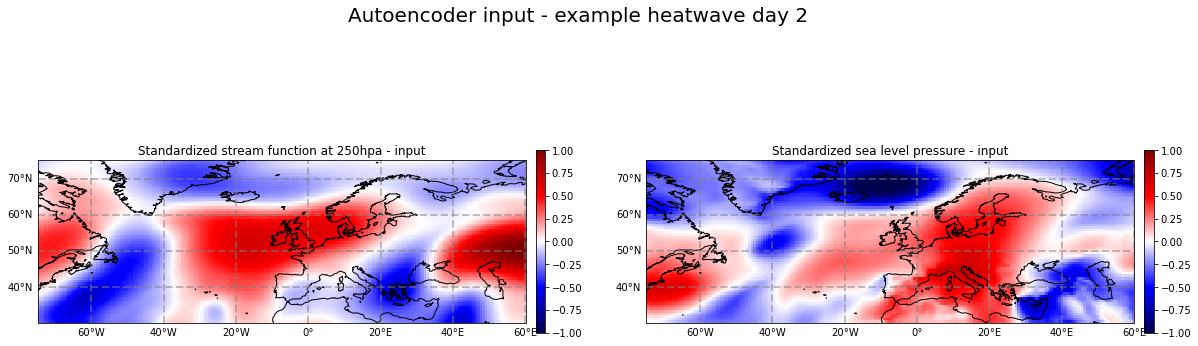

<Figure size 432x288 with 0 Axes>

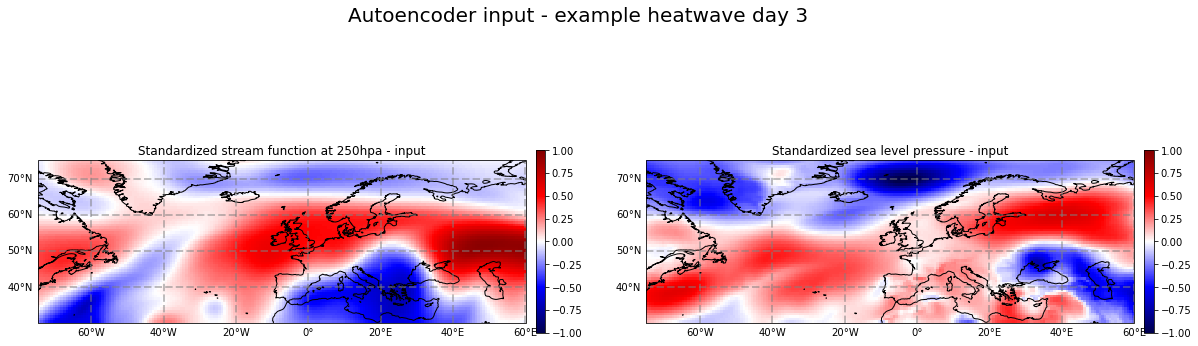

<Figure size 432x288 with 0 Axes>

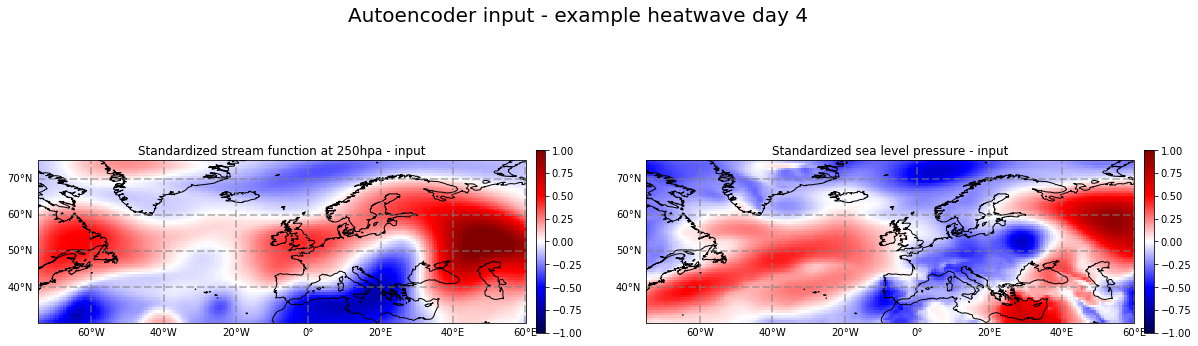

<Figure size 432x288 with 0 Axes>

In [41]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import warnings
warnings.filterwarnings("ignore")

%matplotlib inline

lons = np.array([-74.53125 , -73.828125, -73.125   , -72.421875,
                   -71.71875 , -71.015625, -70.3125  , -69.609375,
                   -68.90625 , -68.203125, -67.5     , -66.796875,
                   -66.09375 , -65.390625, -64.6875  , -63.984375,
                   -63.28125 , -62.578125, -61.875   , -61.171875,
                   -60.46875 , -59.765625, -59.0625  , -58.359375,
                   -57.65625 , -56.953125, -56.25    , -55.546875,
                   -54.84375 , -54.140625, -53.4375  , -52.734375,
                   -52.03125 , -51.328125, -50.625   , -49.921875,
                   -49.21875 , -48.515625, -47.8125  , -47.109375,
                   -46.40625 , -45.703125, -45.      , -44.296875,
                   -43.59375 , -42.890625, -42.1875  , -41.484375,
                   -40.78125 , -40.078125, -39.375   , -38.671875,
                   -37.96875 , -37.265625, -36.5625  , -35.859375,
                   -35.15625 , -34.453125, -33.75    , -33.046875,
                   -32.34375 , -31.640625, -30.9375  , -30.234375,
                   -29.53125 , -28.828125, -28.125   , -27.421875,
                   -26.71875 , -26.015625, -25.3125  , -24.609375,
                   -23.90625 , -23.203125, -22.5     , -21.796875,
                   -21.09375 , -20.390625, -19.6875  , -18.984375,
                   -18.28125 , -17.578125, -16.875   , -16.171875,
                   -15.46875 , -14.765625, -14.0625  , -13.359375,
                   -12.65625 , -11.953125, -11.25    , -10.546875,
                    -9.84375 ,  -9.140625,  -8.4375  ,  -7.734375,
                    -7.03125 ,  -6.328125,  -5.625   ,  -4.921875,
                    -4.21875 ,  -3.515625,  -2.8125  ,  -2.109375,
                    -1.40625 ,  -0.703125,   0.      ,   0.703125,
                     1.40625 ,   2.109375,   2.8125  ,   3.515625,
                     4.21875 ,   4.921875,   5.625   ,   6.328125,
                     7.03125 ,   7.734375,   8.4375  ,   9.140625,
                     9.84375 ,  10.546875,  11.25    ,  11.953125,
                    12.65625 ,  13.359375,  14.0625  ,  14.765625,
                    15.46875 ,  16.171875,  16.875   ,  17.578125,
                    18.28125 ,  18.984375,  19.6875  ,  20.390625,
                    21.09375 ,  21.796875,  22.5     ,  23.203125,
                    23.90625 ,  24.609375,  25.3125  ,  26.015625,
                    26.71875 ,  27.421875,  28.125   ,  28.828125,
                    29.53125 ,  30.234375,  30.9375  ,  31.640625,
                    32.34375 ,  33.046875,  33.75    ,  34.453125,
                    35.15625 ,  35.859375,  36.5625  ,  37.265625,
                    37.96875 ,  38.671875,  39.375   ,  40.078125,
                    40.78125 ,  41.484375,  42.1875  ,  42.890625,
                    43.59375 ,  44.296875,  45.      ,  45.703125,
                    46.40625 ,  47.109375,  47.8125  ,  48.515625,
                    49.21875 ,  49.921875,  50.625   ,  51.328125,
                    52.03125 ,  52.734375,  53.4375  ,  54.140625,
                    54.84375 ,  55.546875,  56.25    ,  56.953125,
                    57.65625 ,  58.359375,  59.0625  ,  59.765625])
lats = np.array([30.5262516 , 31.22800418, 31.92975673, 32.63150925,
                   33.33326174, 34.0350142 , 34.73676663, 35.43851902,
                   36.14027138, 36.8420237 , 37.54377599, 38.24552823,
                   38.94728044, 39.6490326 , 40.35078471, 41.05253678,
                   41.75428879, 42.45604076, 43.15779267, 43.85954452,
                   44.56129631, 45.26304804, 45.9647997 , 46.66655129,
                   47.3683028 , 48.07005424, 48.7718056 , 49.47355688,
                   50.17530806, 50.87705915, 51.57881013, 52.28056101,
                   52.98231178, 53.68406242, 54.38581295, 55.08756333,
                   55.78931357, 56.49106366, 57.19281359, 57.89456335,
                   58.59631292, 59.2980623 , 59.99981146, 60.7015604 ,
                   61.40330909, 62.10505753, 62.80680568, 63.50855352,
                   64.21030104, 64.9120482 , 65.61379497, 66.31554132,
                   67.01728721, 67.71903259, 68.42077741, 69.12252163,
                   69.82426517, 70.52600796, 71.22774993, 71.92949096,
                   72.63123095, 73.33296977, 74.03470726, 74.73644324])  


to_plot = ["stream_in","psl_in",]    
plotdict = {"stream_in":[stream_in, 221, "stream function at 250hpa - input"], 
           "psl_in":[psl_in, 222, "sea level pressure - input"],}

cmap='seismic'

vmin, vmax = -1,1
for day in range(5):
    
    fig, axes = plt.subplots(1,2, figsize=(20,12))

    for i, var in enumerate(to_plot):
        ax = plt.subplot(plotdict[var][1], projection=ccrs.PlateCarree())
        cs = ax.pcolormesh(lons, lats, plotdict[var][0][day] ,
                 transform=ccrs.PlateCarree(), cmap=cmap, vmin=vmin, vmax=vmax) #min max aanpassen voor norm/stnd method
        ax.coastlines()
        ax.set_title(f"Standardized {plotdict[var][2]}")
        ax.set_xlabel("Longitude")
        ax.set_ylabel("Latitude")
        gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True,
                          linewidth=2, color='gray', alpha=0.5, linestyle='--')
        gl.xlabels_top = False
        gl.ylabels_right = False
        fig.colorbar(cs, ax=ax, fraction=0.018, pad=0.02)


    fig.suptitle(f"Autoencoder input - example heatwave day {day}", fontsize=20)

    plt.show()
    plt.clf()